# Importing Recinos

# Set up the environment

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from unidecode import unidecode

In [2]:
import spacy

In [3]:
spacy.__version__

'3.7.6'

In [4]:
nlp = spacy.load('es_core_news_lg')

# Import the text ($F0$)

In [5]:
recinos_src = f"recinos.txt"

In [6]:
recinos = pd.DataFrame([line.strip() for line in open(recinos_src, "r").readlines()], 
                       columns=['line_str'])
recinos.index.name = "line_num"

In [7]:
recinos.head()

,line_str
line_num,
0,# POPOL VUH: Las antiguas historias de Quiché
1,"# Traducción, introducción y notas de Adrían R..."
2,
3,PREÁMBULO
4,


# Prepare the text

## Clip the cruft 

Here we exclude the footnotes.

In [8]:
recinos

,line_str
line_num,
0,# POPOL VUH: Las antiguas historias de Quiché
1,"# Traducción, introducción y notas de Adrían R..."
2,
3,PREÁMBULO
4,
...,...
3471,"mahabi chi ilbal re Popo Vuh, y la del capítul..."
3472,"ilbal re, qovuh,Popol Vuh u bi cumal. El autor..."
3473,ha tenido que escribirla porque ya no existe e...


In [9]:
a = 3 # By visual inspection
b = 2807 # By visual inspection

In [10]:
recinos = recinos.iloc[a:b].copy().reset_index(drop=True)

In [11]:
recinos

,line_str
0,PREÁMBULO
1,
2,CAPÍTULO PRIMERO
3,
4,Este es el principio de las antiguas historias...
...,...
2799,"Chocoh, que representaba cada uno a su familia."
2800,"Y ésta fue la existencia de los quichés, porqu..."
2801,"tenían antiguamente los reyes,51 pues ha desap..."
2802,"Así, pues, se han acabado todos los del Quiché..."


# Remove arabic numbers

In [12]:
recinos.line_str = recinos.line_str.str.replace(r"\d+", "", regex=True)

## Chunk by Part

In [13]:
recinos['parte'] = recinos.loc[recinos.line_str.str.contains(r"(?:PREÁMBULO|PARTE)", regex=True), 'line_str']
recinos['parte'] = recinos.parte.ffill()

In [14]:
recinos

,line_str,parte
0,PREÁMBULO,PREÁMBULO
1,,PREÁMBULO
2,CAPÍTULO PRIMERO,PREÁMBULO
3,,PREÁMBULO
4,Este es el principio de las antiguas historias...,PREÁMBULO
...,...,...
2799,"Chocoh, que representaba cada uno a su familia.",CUARTA PARTE
2800,"Y ésta fue la existencia de los quichés, porqu...",CUARTA PARTE
2801,"tenían antiguamente los reyes, pues ha desapar...",CUARTA PARTE
2802,"Así, pues, se han acabado todos los del Quiché...",CUARTA PARTE


## Chunk by Chapter

In [15]:
recinos['capit'] = recinos.loc[recinos.line_str.str.contains(r"(?:CAPÍTULO|CAPITULO)", regex=True)].line_str
recinos['capit'] = recinos.capit.ffill()

In [16]:
recinos = recinos.dropna(subset=['parte'])

In [17]:
recinos

,line_str,parte,capit
0,PREÁMBULO,PREÁMBULO,NaN
1,,PREÁMBULO,NaN
2,CAPÍTULO PRIMERO,PREÁMBULO,CAPÍTULO PRIMERO
3,,PREÁMBULO,CAPÍTULO PRIMERO
4,Este es el principio de las antiguas historias...,PREÁMBULO,CAPÍTULO PRIMERO
...,...,...,...
2799,"Chocoh, que representaba cada uno a su familia.",CUARTA PARTE,CAPÍTULO XII
2800,"Y ésta fue la existencia de los quichés, porqu...",CUARTA PARTE,CAPÍTULO XII
2801,"tenían antiguamente los reyes, pues ha desapar...",CUARTA PARTE,CAPÍTULO XII
2802,"Así, pues, se han acabado todos los del Quiché...",CUARTA PARTE,CAPÍTULO XII


## Remove extra lines

In [18]:
recinos = recinos[~recinos.capit.isna()]
recinos = recinos.loc[~(recinos.line_str == recinos.parte)]
recinos = recinos.loc[~(recinos.line_str == recinos.capit)]
recinos = recinos.loc[~(recinos.line_str == '')]

In [19]:
recinos

,line_str,parte,capit
4,Este es el principio de las antiguas historias...,PREÁMBULO,CAPÍTULO PRIMERO
5,"y comenzaremos las antiguas historias, el pri...",PREÁMBULO,CAPÍTULO PRIMERO
6,"de Quiché, por las tribus de la nación quiché.",PREÁMBULO,CAPÍTULO PRIMERO
7,"Y aquí traeremos la manifestación, la publicac...",PREÁMBULO,CAPÍTULO PRIMERO
8,"por Tzacol, Bitol, Alom, Qaholom, que se llama...",PREÁMBULO,CAPÍTULO PRIMERO
...,...,...,...
2798,"y el Nim-Chocoh-Ahau de los Ahau-Quiché, que e...",CUARTA PARTE,CAPÍTULO XII
2799,"Chocoh, que representaba cada uno a su familia.",CUARTA PARTE,CAPÍTULO XII
2800,"Y ésta fue la existencia de los quichés, porqu...",CUARTA PARTE,CAPÍTULO XII
2801,"tenían antiguamente los reyes, pues ha desapar...",CUARTA PARTE,CAPÍTULO XII


## Convert Division Names to Integers

Handle Parts

In [20]:
# recinos.parte.value_counts()

In [21]:
part_seq = {
    'SEGUNDA PARTE': 2,
    'CUARTA PARTE': 4,
    'PRIMERA PARTE': 1,
    'TERCERA PARTE': 3,
    'PREÁMBULO': 0
}

In [22]:
recinos['parte'] = recinos['parte'].apply(lambda x: part_seq[x])

In [23]:
recinos

,line_str,parte,capit
4,Este es el principio de las antiguas historias...,0,CAPÍTULO PRIMERO
5,"y comenzaremos las antiguas historias, el pri...",0,CAPÍTULO PRIMERO
6,"de Quiché, por las tribus de la nación quiché.",0,CAPÍTULO PRIMERO
7,"Y aquí traeremos la manifestación, la publicac...",0,CAPÍTULO PRIMERO
8,"por Tzacol, Bitol, Alom, Qaholom, que se llama...",0,CAPÍTULO PRIMERO
...,...,...,...
2798,"y el Nim-Chocoh-Ahau de los Ahau-Quiché, que e...",4,CAPÍTULO XII
2799,"Chocoh, que representaba cada uno a su familia.",4,CAPÍTULO XII
2800,"Y ésta fue la existencia de los quichés, porqu...",4,CAPÍTULO XII
2801,"tenían antiguamente los reyes, pues ha desapar...",4,CAPÍTULO XII


Handle Chapters

In [24]:
recinos.loc[recinos.capit.str.match(r"CAP[IÍ]TULO"), 'capit'] = recinos.capit\
    .str.replace(r"CAP[IÍ]TULO ", "", regex=True)

In [25]:
recinos

,line_str,parte,capit
4,Este es el principio de las antiguas historias...,0,PRIMERO
5,"y comenzaremos las antiguas historias, el pri...",0,PRIMERO
6,"de Quiché, por las tribus de la nación quiché.",0,PRIMERO
7,"Y aquí traeremos la manifestación, la publicac...",0,PRIMERO
8,"por Tzacol, Bitol, Alom, Qaholom, que se llama...",0,PRIMERO
...,...,...,...
2798,"y el Nim-Chocoh-Ahau de los Ahau-Quiché, que e...",4,XII
2799,"Chocoh, que representaba cada uno a su familia.",4,XII
2800,"Y ésta fue la existencia de los quichés, porqu...",4,XII
2801,"tenían antiguamente los reyes, pues ha desapar...",4,XII


In [26]:
# recinos.capit.value_counts()

In [27]:
chap_seq = {
    'PRIMERO': 1,
    'I': 1,
    'II': 2,
    'III': 3,
    'IV': 4,
    'V': 5,
    'VI': 6,
    'VII': 7,
    'VIII': 8,
    'IX': 9,
    'X': 10,
    'XI': 11,
    'XII': 12,
    'XIII': 13,
    'XIV': 14
}

In [28]:
recinos['capit'] = recinos['capit'].apply(lambda x: chap_seq[x])

In [29]:
recinos

,line_str,parte,capit
4,Este es el principio de las antiguas historias...,0,1
5,"y comenzaremos las antiguas historias, el pri...",0,1
6,"de Quiché, por las tribus de la nación quiché.",0,1
7,"Y aquí traeremos la manifestación, la publicac...",0,1
8,"por Tzacol, Bitol, Alom, Qaholom, que se llama...",0,1
...,...,...,...
2798,"y el Nim-Chocoh-Ahau de los Ahau-Quiché, que e...",4,12
2799,"Chocoh, que representaba cada uno a su familia.",4,12
2800,"Y ésta fue la existencia de los quichés, porqu...",4,12
2801,"tenían antiguamente los reyes, pues ha desapar...",4,12


## Convert to CHAP table ($F1$)

In [30]:
OHCO = ['parte','capit']
CHAP = recinos.groupby(OHCO).line_str.apply(lambda x: ' '.join(x)).to_frame('doc_str').reindex()
CHAP['n_chars'] = CHAP.doc_str.str.len()
CHAP['n_words'] = CHAP.doc_str.str.split().apply(len)

In [31]:
len(CHAP)

46

In [32]:
# CHAP.n_words.cumsum().plot.bar();

Here's a quick view of the distribution of text by part.

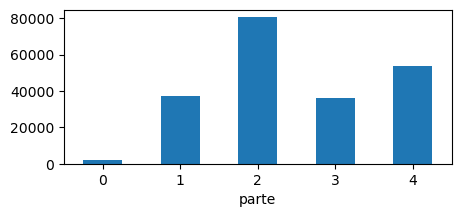

In [33]:
CHAP.groupby(OHCO[:1]).n_chars.sum().plot.bar(rot=0, figsize=(5,2));

# Parse the text

## Convert chapters to SpaCy `Doc` objects

We first apply the model to the texts segmented by chapter.

We use SpaCy, which like many NLP tools, expects data in $F1$ format.

This produces a dataframe of SpaCy Doc objects.

In [34]:
SPACY = CHAP.doc_str.apply(nlp)

## Create TOKEN with SpaCy ($F2$)

Next, we extract sentences and tokens from the Doc objects and put them into F2 structure.

In [35]:
TOKEN = SPACY\
    .apply(lambda x: [sent for sent in x.sents]).apply(pd.Series).stack()\
    .apply(lambda x: [[token.text, token.lemma_, token.pos_, token.dep_] for token in x]).apply(pd.Series).stack()\
    .apply(pd.Series)

In [36]:
TOKEN.head()

0          1     2      3
parte capit                                       
0     1     0 0       Este       este  PRON  nsubj
              1         es        ser   AUX    cop
              2         el         el   DET    det
              3  principio  principio  NOUN   ROOT
              4         de         de   ADP   case

Here, we break down the steps to show how they work.

The pattern is to use a **comprehension to extract elements** from the SpaCy object, \
and then to convert these into a **Series**, \
which is then **stacked** to create a new data frame.

In [37]:
TOKEN.index.names = OHCO + ['sent', 'token']

In [38]:
TOKEN

0          1      2        3
parte capit sent token                                      
0     1     0    0           Este       este   PRON    nsubj
                 1             es        ser    AUX      cop
                 2             el         el    DET      det
                 3      principio  principio   NOUN     ROOT
                 4             de         de    ADP     case
...                           ...        ...    ...      ...
4     12    78   12            se         él   PRON  expl:pv
                 13         llama     llamar   VERB    csubj
                 14         Santa      Santa  PROPN      obj
                 15          Cruz       Cruz  PROPN     flat
                 16             .          .  PUNCT    punct

[42639 rows x 4 columns]

In [39]:
TOKEN.columns = ['token_str', 'token_lemma', 'token_pos', 'token_dep']
TOKEN['term_str'] = TOKEN.token_str.str.replace(r"\W+", "", regex=True).str.lower().apply(unidecode)

In [40]:
TOKEN

token_str token_lemma token_pos token_dep   term_str
parte capit sent token                                                      
0     1     0    0           Este        este      PRON     nsubj       este
                 1             es         ser       AUX       cop         es
                 2             el          el       DET       det         el
                 3      principio   principio      NOUN      ROOT  principio
                 4             de          de       ADP      case         de
...                           ...         ...       ...       ...        ...
4     12    78   12            se          él      PRON   expl:pv         se
                 13         llama      llamar      VERB     csubj      llama
                 14         Santa       Santa     PROPN       obj      santa
                 15          Cruz        Cruz     PROPN      flat       cruz
                 16             .           .     PUNCT     punct           

[42639 rows x 5 columns]

## Investiage parts of speech

In [41]:
POS = TOKEN.token_pos.value_counts().to_frame('n')

In [42]:
POS

,n
token_pos,
PUNCT,6722
NOUN,6194
DET,5318
VERB,4979
ADP,4691
PRON,3466
PROPN,2422
CCONJ,2285
ADV,2210


In [43]:
TOKEN.loc[TOKEN.term_str == 'tohil']

token_str token_lemma token_pos token_dep term_str
parte capit sent token                                                   
3     4     13   6         Tohil       Tohil     PROPN     nsubj    tohil
            17   2         Tohil       Tohil     PROPN     nsubj    tohil
            19   0         Tohil       Tohil     PROPN     nsubj    tohil
            20   22        Tohil       Tohil     PROPN     appos    tohil
                 27        Tohil       Tohil     PROPN      flat    tohil
...                          ...         ...       ...       ...      ...
4     3     34   9         Tohil       Tohil     PROPN      iobj    tohil
      11    2    4         Tohil       Tohil     PROPN      flat    tohil
            5    7         Tohíl       Tohíl     PROPN      nmod    tohil
            15   13        Tohil       Tohil     PROPN       obl    tohil
            31   44        Tohil       Tohil     PROPN      conj    tohil

[76 rows x 5 columns]

In [44]:
PROPN = TOKEN.loc[TOKEN.token_pos == 'PROPN'].term_str.value_counts().to_frame('n')

In [45]:
PROPN

,n
term_str,
senores,129
xibalba,106
hunahpu,88
tohil,76
ixbalanque,71
...,...
fuego,1
admirabanse,1
llenos,1


# Extract other things

## Extract SpaCy's `Vocab` object

In [46]:
VOCABX = pd.DataFrame([[w.text, w.norm_, w.is_stop, w.vector_norm] for w in nlp.vocab if w.is_alpha], columns=['token_str', 'term_str', 'stop', 'vnorm'])
VOCABX.sort_values('vnorm', ascending=False)
VOCABX = VOCABX.set_index('term_str')

SpaCy also includes vectors (embeddings) for each word.

## Extract vectors

In [47]:
VOCAB_VEC = pd.DataFrame(
    [[unidecode(w.text.lower()), w.vector] for w in nlp.vocab if w.is_alpha], 
    columns=['term_str', 'vnorm'])\
    .set_index('term_str')\
    .vnorm.apply(pd.Series)

In [48]:
VOCAB_VEC = VOCAB_VEC.drop_duplicates()

In [49]:
VOCAB_VEC.loc[VOCAB_VEC.index.duplicated()]

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
term_str,,,,,,,,,,,,,,,,,,,,,
buhos,-0.68233,-0.79662,-0.82534,1.054500,1.056200,0.41921,-1.41530,-0.25189,2.14930,0.32295,...,-0.87724,-0.22408,-0.49380,0.841300,-1.07190,0.17830,0.44859,-0.016152,-0.49047,1.449900
bajaron,1.85620,-0.81965,2.75130,0.423880,-0.790800,1.34870,-0.17335,-2.59690,-0.95307,0.90232,...,-2.60580,0.30622,3.00590,2.582500,2.77510,-2.48900,0.71924,2.405300,-1.94340,0.642750
junto,2.59940,1.12190,-0.11877,1.186700,0.396390,1.66010,0.56173,-1.61650,1.97330,-0.54765,...,0.19145,0.39045,1.57430,-0.413910,3.09360,-1.47960,-0.46227,-0.426530,-1.80840,3.809900
es,-0.98123,-1.24650,-5.57190,-0.857710,-0.045647,-3.83610,4.47960,5.29280,-2.11130,2.81420,...,-12.34100,-6.39330,-5.91760,4.344500,-0.65008,6.72990,1.19030,-2.903100,1.77140,3.699100
de,-5.64010,6.06580,3.69420,1.466500,-8.863300,8.20010,5.47080,2.15090,3.48500,3.98340,...,-3.67690,-1.10580,1.68740,-4.704100,4.14120,3.28390,-1.49220,0.084526,5.45410,2.262500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
que,-3.80440,-1.40350,-2.43730,0.441550,-3.579600,-3.01780,-1.96850,4.01260,-0.90517,1.43970,...,0.48494,-2.06700,3.17480,0.506480,-5.04830,0.20866,1.27080,-3.012700,1.06470,-2.070200
llego,1.43090,0.78988,0.71735,-1.337500,-1.165700,1.55590,-0.37291,-2.76340,2.06890,-2.38200,...,-1.54260,-1.76260,1.73770,0.002085,3.07930,-1.99350,-2.05480,1.644000,-0.92863,1.446500
verdaderamente,1.02250,1.45350,-1.46040,-0.697340,0.312200,-0.13648,-2.65000,1.51660,-0.52939,3.09720,...,2.05180,-0.21363,0.26611,-0.350640,0.11922,-1.71830,-0.26262,0.668230,0.03970,-0.984470


## Extract VOCAB the traditional way

In [50]:
VOCAB = TOKEN.term_str.value_counts().to_frame('n')
VOCAB = VOCAB.loc[VOCAB.index != ""]
VOCAB.index.name = 'term_str'
VOCAB = VOCAB.sort_index()

In [51]:
VOCAB.head(10)

,n
term_str,
a,840
abajo,3
abandonada,1
abandonado,1
abandonando,1
abandonaran,1
abandonaron,2
abarcar,1
abejas,3


In [52]:
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['h'] = VOCAB.p * VOCAB.i
VOCAB['n_chars'] = VOCAB.index.str.len()

In [53]:
VOCAB

,n,p,i,h,n_chars
term_str,,,,,
a,840,0.023471,5.412983,0.127048,1
abajo,3,0.000084,13.542266,0.001135,5
abandonada,1,0.000028,15.127229,0.000423,10
abandonado,1,0.000028,15.127229,0.000423,10
abandonando,1,0.000028,15.127229,0.000423,11
...,...,...,...,...,...
zotziha,1,0.000028,15.127229,0.000423,7
zotzu,1,0.000028,15.127229,0.000423,5
ztayul,1,0.000028,15.127229,0.000423,6


In [54]:
VOCAB[VOCAB.n_chars >= 15]

,n,p,i,h,n_chars
term_str,,,,,
agradecimientos,2,0.000056,14.127229,0.000789,15
ahauahgucumatzr,1,0.000028,15.127229,0.000423,15
ahauahtzicvinac,1,0.000028,15.127229,0.000423,15
ahtzicvinacahau,1,0.000028,15.127229,0.000423,15
alegrograndemente,1,0.000028,15.127229,0.000423,17
animadversiones,1,0.000028,15.127229,0.000423,15
apresuradamente,1,0.000028,15.127229,0.000423,15
chabicacchihunahpu,1,0.000028,15.127229,0.000423,18
desgraciadamente,1,0.000028,15.127229,0.000423,16


In [55]:
px.scatter(VOCAB.reset_index(), 'i', 'n_chars', hover_name='term_str', height=500, width=600, trendline='lowess')

# POS in VOCAB

In [56]:
VOCAB_POS = TOKEN.value_counts(['term_str', 'token_pos']).unstack(fill_value=0)
VOCAB_POS = VOCAB_POS[VOCAB_POS.PUNCT == 0]

In [57]:
VOCAB.join(VOCAB_POS)

,n,p,i,h,n_chars,ADJ,ADP,ADV,AUX,CCONJ,...,NOUN,NUM,PRON,PROPN,PUNCT,SCONJ,SPACE,SYM,VERB,X
term_str,,,,,,,,,,,,,,,,,,,,,
a,840,0.023471,5.412983,0.127048,1,0,839,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abajo,3,0.000084,13.542266,0.001135,5,0,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
abandonada,1,0.000028,15.127229,0.000423,10,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
abandonado,1,0.000028,15.127229,0.000423,10,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
abandonando,1,0.000028,15.127229,0.000423,11,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zotziha,1,0.000028,15.127229,0.000423,7,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
zotzu,1,0.000028,15.127229,0.000423,5,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
ztayul,1,0.000028,15.127229,0.000423,6,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [58]:
# if 'stop' not in VOCAB.columns:
#     VOCAB = VOCAB.join(VOCABX.sort_index()[['stop']])
#     VOCAB = VOCAB.drop_duplicates()

In [59]:
# VOCAB

## Generate BOW and compute DFIDF

In [60]:
BOW = TOKEN.groupby(OHCO+['term_str']).term_str.count().to_frame('n').unstack(fill_value=0)
BOW.columns = BOW.columns.droplevel(0)

In [61]:
DOC = pd.DataFrame(index=BOW.index)

In [62]:
N_docs = len(DOC)

In [63]:
VOCAB['df'] = BOW.astype(bool).sum()
VOCAB['dfidf'] = VOCAB.df * np.log2(N_docs/VOCAB.df)
VOCAB['z'] = (VOCAB.dfidf - VOCAB.dfidf.mean()) / VOCAB.dfidf.std()

In [64]:
VOCAB['dp'] = VOCAB.df / N_docs # VOCAB.df.sum()
VOCAB['di'] = np.log2(1/VOCAB.dp)
VOCAB['dh'] = VOCAB.dp * VOCAB.di

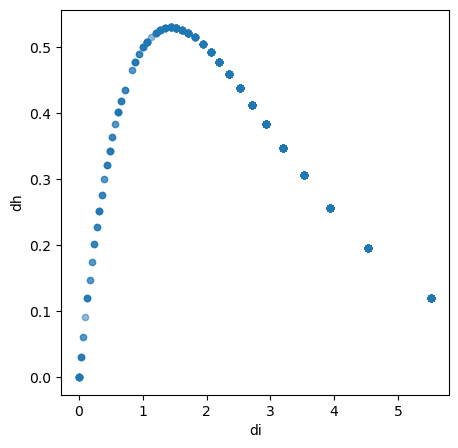

In [65]:
VOCAB.plot.scatter('di', 'dh', figsize=(5,5), alpha=0.5);

In [66]:
VOCAB[VOCAB.dh > .45].sample(10)

,n,p,i,h,n_chars,df,dfidf,z,dp,di,dh
term_str,,,,,,,,,,,
quienes,21,0.000587,10.734911,0.006299,7,16,24.376991,3.161230,0.347826,1.523562,0.529935
vuestras,9,0.000251,11.957304,0.003007,8,9,21.182733,2.523260,0.195652,2.353637,0.460494
desde,24,0.000671,10.542266,0.007070,5,14,24.026898,3.091308,0.304348,1.716207,0.522324
entre,71,0.001984,8.977481,0.017810,5,25,21.992644,2.685019,0.543478,0.879706,0.478101
cavec,18,0.000503,10.957304,0.005511,5,9,21.182733,2.523260,0.195652,2.353637,0.460494
dieron,31,0.000866,10.173032,0.008812,6,23,23.000000,2.886212,0.500000,1.000000,0.500000
vuestros,27,0.000754,10.372341,0.007825,8,13,23.700589,3.026136,0.282609,1.823122,0.515230
entraron,16,0.000447,11.127229,0.004975,8,10,22.016339,2.689751,0.217391,2.201634,0.478616
dos,69,0.001928,9.018704,0.017388,3,25,21.992644,2.685019,0.543478,0.879706,0.478101


In [67]:
VOCAB.sort_values('dh', ascending=False).head(20)

,n,p,i,h,n_chars,df,dfidf,z,dp,di,dh
term_str,,,,,,,,,,,
nuevo,23,0.000643,10.603667,0.006815,5,17,24.413685,3.168558,0.369565,1.436099,0.530732
hacer,28,0.000782,10.319874,0.008074,5,17,24.413685,3.168558,0.369565,1.436099,0.530732
dios,57,0.001593,9.294339,0.014803,4,17,24.413685,3.168558,0.369565,1.436099,0.530732
quien,24,0.000671,10.542266,0.007070,5,17,24.413685,3.168558,0.369565,1.436099,0.530732
ixbalanque,71,0.001984,8.977481,0.017810,10,17,24.413685,3.168558,0.369565,1.436099,0.530732
cielo,55,0.001537,9.345869,0.014363,5,17,24.413685,3.168558,0.369565,1.436099,0.530732
nuestro,24,0.000671,10.542266,0.007070,7,17,24.413685,3.168558,0.369565,1.436099,0.530732
muerte,27,0.000754,10.372341,0.007825,6,17,24.413685,3.168558,0.369565,1.436099,0.530732
vinieron,31,0.000866,10.173032,0.008812,8,17,24.413685,3.168558,0.369565,1.436099,0.530732


In [68]:
VOCAB['stop'] = False
VOCAB.loc[VOCAB.dh <= 0.12, 'stop'] = True

In [69]:
VOCAB[VOCAB.stop == True].index

Index(['a', 'al', 'asi', 'con', 'cuando', 'de', 'del', 'el', 'en', 'esta',
       'la', 'las', 'lo', 'los', 'no', 'por', 'que', 'se', 'su', 'sus', 'una',
       'y'],
      dtype='object', name='term_str')

# Visualize Embeddings

In [70]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [71]:
perplexity=10
n_iter=300
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity, n_iter=n_iter, init='pca', learning_rate='auto')
reduced_embeddings = tsne.fit_transform(VOCAB_VEC.values)

/opt/anaconda3/envs/polo/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:991: FutureWarning:

The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.



In [72]:
NONSTOPS = VOCAB.loc[VOCAB.stop == False].index.to_list()

In [73]:
DF = pd.DataFrame(reduced_embeddings, columns=['x', 'y'], index=VOCAB_VEC.index).join(VOCAB)

In [74]:
DF

,x,y,n,p,i,h,n_chars,df,dfidf,z,dp,di,dh,stop
term_str,,,,,,,,,,,,,,
a,-5.178149,-6.118169,840.0,0.023471,5.412983,0.127048,1.0,45.0,1.426899,-1.422448,0.978261,0.031709,0.031020,True
a,2.603541,1.784739,840.0,0.023471,5.412983,0.127048,1.0,45.0,1.426899,-1.422448,0.978261,0.031709,0.031020,True
a,2.306222,5.445239,840.0,0.023471,5.412983,0.127048,1.0,45.0,1.426899,-1.422448,0.978261,0.031709,0.031020,True
abajo,0.938560,1.237641,3.0,0.000084,13.542266,0.001135,5.0,3.0,11.815798,0.652462,0.065217,3.938599,0.256865,False
abandonada,-0.505757,-0.654444,1.0,0.000028,15.127229,0.000423,10.0,1.0,5.523562,-0.604247,0.021739,5.523562,0.120077,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zapato,0.175355,-5.813991,1.0,0.000028,15.127229,0.000423,6.0,1.0,5.523562,-0.604247,0.021739,5.523562,0.120077,False
zapotes,-1.285678,-7.582994,2.0,0.000056,14.127229,0.000789,7.0,2.0,9.047124,0.099492,0.043478,4.523562,0.196677,False
zarzas,1.262325,-8.595299,2.0,0.000056,14.127229,0.000789,6.0,1.0,5.523562,-0.604247,0.021739,5.523562,0.120077,False


In [75]:
fig = px.scatter(DF.reset_index().sort_values('dh', ascending=False).head(1000), 
           'x', 'y', 
           color='dfidf',
           size='df',
           text='term_str', 
           height=1000)
fig.update_traces(textposition='top center')
fig.show()

# Create DTM

In [76]:
DTM = TOKEN[TOKEN.token_pos.isin(['NOUN','PROPN','VERB']) & (TOKEN.term_str != '')].groupby(OHCO[:2]+['term_str']).term_str.count().unstack(fill_value=0)
STOP = VOCABX[VOCABX.stop == True].index
DTM = DTM[list(set(DTM.columns) - set(STOP))]

In [77]:
# DTM

# Create TFIDF

In [78]:
from sklearn.preprocessing import normalize

In [79]:
TFIDF = DTM * np.log2(len(DTM)/VOCAB.loc[DTM.columns].df)
TFIDF = pd.DataFrame(normalize(TFIDF, norm='l2', axis=1), index=TFIDF.index, columns=TFIDF.columns)
VOCAB['tfidf_mean'] = TFIDF.mean()

# Save

In [80]:
tables = [
    (CHAP, 'CHAP'),
    (TOKEN, 'TOKEN'),
    (VOCAB, 'VOCAB'),
    (VOCABX, 'VOCABX'),
    (BOW, 'BOW'),
    (VOCAB_VEC, 'VOCAB_VEC'),
    (DTM, 'DTM'),
    (TFIDF, 'TFIDF')
]

In [81]:
for df, df_name in tables:
    df.to_csv(f"recinos-{df_name}.csv", index=True)
    df.to_pickle(f"recinos-{df_name}.pickle")

In [82]:
SPACY.to_pickle('spacy.pickle')

In [83]:
with open(f"recinos-DOC_idx.txt", "w") as out:
    out.write(",".join(DOC.index.names))

# Groups for SPAN 4665

In [84]:
runtot = 0
group = 1
data = []
unit_max = 1350 #CHAP.n_words.sum() / 20
for idx, row in CHAP.iterrows():
    runtot += row.n_words
    data.append((idx[0], idx[1], group))
    if runtot > unit_max:
        group += 1
        runtot = 0

In [85]:
CHAP['edit_group'] = pd.DataFrame(data, columns=OHCO + ['edit_group']).set_index(OHCO)

In [86]:
GROUP = CHAP.groupby('edit_group').n_words.sum().to_frame('word_count')

In [87]:
CHAP.edit_group.unstack(fill_value='')

capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14
parte,,,,,,,,,,,,,,
0,1,,,,,,,,,,,,,
1,1,1,2,2,2,2,3,3,4,,,,,
2,4,5,6,6,7,8,9,9,10,10,11,11,11,12
3,12,12,13,13,13,14,14,14,15,15,,,,
4,16,16,17,17,17,18,18,19,19,19,20,20,,


In [88]:
CHAP['edit_unit'] = CHAP.index.values

In [89]:
GROUP['chaps'] = CHAP.groupby('edit_group').edit_unit.apply(lambda x: ' '.join(map(str,x)))

In [90]:
GROUP['text_frac'] = np.round(GROUP.word_count / GROUP.word_count.sum(), 3)

In [91]:
GROUP['z'] = (GROUP.word_count - GROUP.word_count.mean()) / GROUP.word_count.std()

<Axes: ylabel='edit_group'>

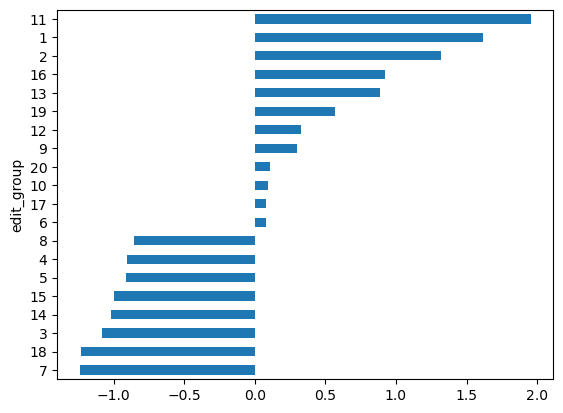

In [92]:
GROUP.z.sort_values().plot.barh()

In [93]:
GROUP

,word_count,chaps,text_frac,z
edit_group,,,,
1,2280,"(0, 1) (1, 1) (1, 2)",0.064,1.615039
2,2190,"(1, 3) (1, 4) (1, 5) (1, 6)",0.061,1.318641
3,1460,"(1, 7) (1, 8)",0.041,-1.085475
4,1515,"(1, 9) (2, 1)",0.042,-0.904343
5,1512,"(2, 2)",0.042,-0.914223
6,1813,"(2, 3) (2, 4)",0.051,0.077063
7,1413,"(2, 5)",0.039,-1.240260
8,1530,"(2, 6)",0.043,-0.854943
9,1880,"(2, 7) (2, 8)",0.053,0.297715


In [94]:
groups = """
Group 1	Walter, Tommy, Parker, Erin
Group 2	Ella, Moira, Filadelfia, Audrey
Group 3	Angie, Nick, Madeline
Group 4	Jack, Alex, Robert
Group 5	Ivy, Luke, Brenna
Group 6	Grayson, Charlotte, Melanie
""".split("\n")[1:-1]

In [95]:
G = pd.DataFrame([g.replace("\t", ", ").split(", ") for g in groups]).set_index(0).stack().to_frame('student').reset_index()

In [96]:
G.index = pd.Index(range(1,21))

In [97]:
G.columns = ['group', 'member_num', 'student']

In [98]:
G

,group,member_num,student
1,Group 1,1,Walter
2,Group 1,2,Tommy
3,Group 1,3,Parker
4,Group 1,4,Erin
5,Group 2,1,Ella
6,Group 2,2,Moira
7,Group 2,3,Filadelfia
8,Group 2,4,Audrey
9,Group 3,1,Angie
10,Group 3,2,Nick


In [99]:
GROUP = GROUP.join(G)

In [100]:
GROUP.to_html("recinos-groups.html")

In [101]:
GROUP[['word_count','chaps', 'group', 'student']] 

,word_count,chaps,group,student
edit_group,,,,
1,2280,"(0, 1) (1, 1) (1, 2)",Group 1,Walter
2,2190,"(1, 3) (1, 4) (1, 5) (1, 6)",Group 1,Tommy
3,1460,"(1, 7) (1, 8)",Group 1,Parker
4,1515,"(1, 9) (2, 1)",Group 1,Erin
5,1512,"(2, 2)",Group 2,Ella
6,1813,"(2, 3) (2, 4)",Group 2,Moira
7,1413,"(2, 5)",Group 2,Filadelfia
8,1530,"(2, 6)",Group 2,Audrey
9,1880,"(2, 7) (2, 8)",Group 3,Angie


In [102]:
index = {parte:capit for parte, capit in CHAP.index}

In [103]:
for parte in index:
    print(f"-Parte {parte}")
    for capit in range(index[parte]):
        print(f"--{capit+1}")

-Parte 0
--1
-Parte 1
--1
--2
--3
--4
--5
--6
--7
--8
--9
-Parte 2
--1
--2
--3
--4
--5
--6
--7
--8
--9
--10
--11
--12
--13
--14
-Parte 3
--1
--2
--3
--4
--5
--6
--7
--8
--9
--10
-Parte 4
--1
--2
--3
--4
--5
--6
--7
--8
--9
--10
--11
--12
